# Scramblers and the locking of metrological information — analog, digital, and the Haar limit

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien)

*Quantum Many-Body Simulation — Chapter 10 — Quantum metrology protocols*

## 1. Introduction and motivation

A metrological probe stores information about a parameter $\theta$ in correlations between its particles.
Notebook 34 built the best possible one: $N$ atoms twisted into a Schrodinger-cat state whose quantum Fisher
information reaches the Heisenberg value $F_Q=N^2$. Notebook 37 asked what survives when particles are *lost*.
This notebook asks a different question, and one that a laboratory faces whether or not it loses anything:

> The probe keeps evolving. Atoms interact with each other, a trap is imperfect, a circuit runs for longer than
> it should. The evolution is unitary, so no information is destroyed. How long before the phase can no longer
> be read out from any small piece of the register — and does the answer depend on *how* the probe is stirred?

The phenomenon is called **locking**. After enough scrambling, the information about $\theta$ is still there —
a unitary is invertible — but it has been pushed into correlations so global that no subsystem smaller than
about half the register retains any of it. Read out ten of twenty atoms and you learn nothing at all; read out
eleven and you learn almost everything. The transition is sharp and it sits at $k=N/2$.

Notebook 35 established the endpoint of this process for one particular stirrer, a global Haar-random unitary,
and observed the half-system threshold. That notebook was about *where the information went*. This one is about
**how it gets there**: the dynamics of locking, the two physically distinct routes to it, and the structural
property of the state that controls it.

### The three questions

1. **What is the locked curve?** We define the *locking curve* $F_k/F_N$ — the quantum Fisher information
   retained by $k$ qubits of the register, relative to the whole — and measure it for Haar-random states. This
   is the fixed point that every scrambler is trying to reach.
2. **How is locking reached, in time and in depth?** Two scramblers, as different as two scramblers can be:
   an **analog** one, a chaotic spin chain evolving continuously under a non-integrable Hamiltonian, and a
   **digital** one, a brick-wall circuit built from discrete gate layers. For the digital case we compare three
   gate sets — Haar-random two-qubit gates, Clifford layers, and the non-Clifford $H\vert T\vert\mathrm{CNOT}$
   layer — because they differ in a way that matters: Clifford circuits are classically simulable and produce
   states with no *magic*, and we can ask whether that shows up in the locking curve.
3. **What controls it?** The candidate mechanism is the **volume law**: locking should set in when the
   entanglement entropy of a half of the register becomes proportional to $N$ rather than to the boundary. We
   measure entropy and locking side by side and find that the correspondence is real but *not* simultaneous —
   the entropy saturates first, and the metrological information keeps leaking out of small subsystems
   afterwards. Section 7 measures how large that lag is rather than asserting it.

### What you will learn

*Physics*

* what locking of metrological information means, and why it is a statement about subsystems rather than about
  the state as a whole;
* the locking curve of a Haar-random state, its threshold at half the register, and the reason the threshold is
  there (a reduced state of fewer than half the qubits of a random state is exponentially close to maximally
  mixed, and a maximally mixed state has zero quantum Fisher information for every generator);
* that an integrable and a chaotic chain lock differently, and that a chain which cannot scramble does not lock
  at all, however long it is evolved;
* that Clifford circuits lock a phase-imprinted GHZ state into a step function with exactly-zero plateaus, while
  circuits with magic produce the smooth Haar curve — the locking curve sees the difference between a stabilizer
  state and a generic one;
* that entanglement entropy saturating at its Page value does **not** imply that the metrological information is
  locked: measured at $N=12$, the half-chain entropy is within a few per cent of Page while a quarter of the
  register still carries an order of magnitude more phase information than the Haar value.

*Numerical methods*

* the symmetric-logarithmic-derivative quantum Fisher information of a reduced state, evaluated without ever
  building the reduced density matrix of the larger half, by a thin QR onto the active subspace;
* the cost argument that makes the whole locking curve $k=0,\dots,N$ cost the same as its most expensive point;
* second-order Trotter-Suzuki evolution of a disordered, non-integrable chain, and how to choose $dt$ by
  measuring the error rather than by trusting the order;
* brick-wall circuits over three gate sets, and sampling the single-qubit Clifford group;
* averaging over disorder and circuit realisations with honest standard errors.

*Implementation practice*

* `lax.scan` over Trotter steps with the gate list closed over, so the step compiles once;
* `jit` over a whole circuit layer, and why the brick-wall loop must be unrolled at trace time;
* a reduced-state quantity evaluated for every $k$ in one pass, reusing one application of the generator;
* `vmap` over disorder realisations, and the discipline of splitting keys explicitly so that a figure redrawn
  tomorrow is the same figure.

### Prerequisites
* [01 — JAX from scratch](../ch01_computational_toolbox/01_jax_from_scratch.ipynb): `jit`, `vmap`, `lax.scan`, PRNG keys;
* [06 — states, observables and entanglement](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb):
  reduced density matrices, Schmidt values, entanglement entropy, the Page value;
* [10 — random unitaries and random circuits](../ch04_digital_quantum_circuits/10_random_unitaries_and_random_circuits.ipynb):
  the Haar measure, Mezzadri's recipe, the single-qubit Clifford group, brick-wall circuits;
* [12 — TEBD](../ch05_ground_states_and_unitary_dynamics/12_tebd_trotter_suzuki.ipynb) and
  [15 — quench dynamics](../ch05_ground_states_and_unitary_dynamics/15_quench_dynamics_spin_chains.ipynb):
  Trotter-Suzuki evolution, entanglement growth, integrable versus chaotic chains;
* [29 — quantum Fisher information](../ch10_quantum_metrology_protocols/29_quantum_fisher_information.ipynb) and
  [30 — QFI from the SLD](../ch10_quantum_metrology_protocols/30_qfi_from_the_sld_prepare_encode_estimate.ipynb):
  $F_Q=4\,\mathrm{Var}(G)$ for pure states, the symmetric logarithmic derivative for mixed ones;
* [35 — scrambling a metrological probe](../ch10_quantum_metrology_protocols/35_oat_plus_haar_scrambling.ipynb):
  the unitary-invariance identity and the endpoint of scrambling under a global Haar unitary. Section 3 recalls
  everything this notebook needs from it.

**What comes next.** [39 — QFI spreading in spin chains](../ch10_quantum_metrology_protocols/39_qfi_spreading_in_spin_chains.ipynb)
follows the same information through a chain with long-range couplings, where the light cone itself changes shape.

**Conventions.** Qubit $q$ = tensor axis $q$, $0$-indexed; $\vert0\rangle$ is the $+1$ eigenstate of $Z$.
Collective spin operators are $J_a=\tfrac12\sum_q\sigma^a_q$, so the standard quantum limit is $F_Q=N$ and the
Heisenberg limit $F_Q=N^2$. The parameter is imprinted on the **whole** register by $U(\theta)=e^{-i\theta J_z}$
unless stated otherwise, and only then is a subsystem selected. "Keeping $k$ qubits" always means keeping the
**last** $k$ tensor axes, $q=N-k,\dots,N-1$.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels: enough for N<=26 (pure) / N<=13 (DM)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and notebook helpers

From the engine we take the state constructors, `apply_gate` and `apply_gates` (the einsum that applies a small
matrix to chosen axes, and a circuit as a list of them), `apply_collective` for the matrix-free $\sum_qP_q$,
`qfi_pure`, `oat_evolve` for the exact one-axis-twisting propagator, `tebd_gates` for the Trotter step,
`haar_unitary`, `single_qubit_cliffords`, and the entropy routines. Everything specific to locking is built
below.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP  (auto-generated from quantum_engine.py -- derived step by step in Part 0)
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
T = jnp.array([[1, 0], [0, jnp.exp(1j * jnp.pi / 4)]], dtype=CDTYPE)  # pi/8 gate, T^2 = S (non-Clifford!)
CNOT = jnp.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]], dtype=CDTYPE)
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "Ab,abc->aAc"          A = new (output) index of qubit 1
        N=4, q=(1,3)    :  "ABbd,abcd->aAcB"      A,B = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter; U carries (new letters)+(old letters of the targets); the output is psi's
    labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def ghz_state(N):
    """GHZ state (|0...0> + |1...1>)/sqrt(2): two non-zero entries of the rank-N tensor."""
    psi = jnp.zeros((2,) * N, dtype=CDTYPE)
    return psi.at[(0,) * N].set(1 / jnp.sqrt(2.0)).at[(1,) * N].set(1 / jnp.sqrt(2.0))

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def schmidt_values(psi, subsystem):
    """Schmidt coefficients of the bipartition A|B with A = `subsystem`.

    MATH   Group the tensor axes into a matrix  M[(a),(b)] = psi[a,b]  of shape (2^|A|, 2^|B|).
           Its SVD  M = U diag(lambda) V^dag  IS the Schmidt decomposition
               |psi> = sum_k lambda_k |u_k>_A |v_k>_B ,     rho_A has eigenvalues lambda_k^2.
    IMPLEMENTATION   transpose (A axes first) -> reshape -> svd.   No density matrix needed.
    """
    A = tuple(int(q) for q in subsystem)
    B = tuple(q for q in range(psi.ndim) if q not in A)
    M = jnp.transpose(psi, A + B).reshape(2 ** len(A), -1)
    return jnp.linalg.svd(M, compute_uv=False)

def entanglement_entropy(psi, subsystem, base=2.0):
    """Entanglement entropy S_A = -sum_k p_k log p_k with p_k = lambda_k^2 (squared Schmidt values).
    Product state: 0.  Bell/GHZ across any cut: 1 bit.  Random state: ~ |A| - 1/(2 ln2) 2^{|A|-|B|} (Page)."""
    p = jnp.clip(schmidt_values(psi, subsystem) ** 2, 1e-16, None)
    return -jnp.sum(p * jnp.log(p)) / jnp.log(base)


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def _expm_herm(h, tau):
    """exp(-i tau h) for a SMALL Hermitian matrix: h = V w V^dag  =>  V exp(-i tau w) V^dag."""
    w, v = jnp.linalg.eigh(jnp.asarray(h, dtype=CDTYPE))
    return (v * jnp.exp(-1j * tau * w)) @ v.conj().T

def tebd_gates(terms, dt, order=2):
    """Gate sequence of ONE Trotter-Suzuki (TEBD) step for H = sum_k h_k.

    MATH   exp(-i H dt) cannot be split exactly because [h_k, h_l] != 0, but (BCH formula):
        order 1:  prod_k e^{-i h_k dt}                                       local error O(dt^2), global O(dt)
        order 2:  prod_k e^{-i h_k dt/2} * prod_k(reversed) e^{-i h_k dt/2}  local O(dt^3), global O(dt^2)
        order 4:  S2(s dt)^2 S2((1-4s) dt) S2(s dt)^2,  s = 1/(4 - 4^{1/3})  (Suzuki)   global O(dt^4)
    Each factor is a 2x2 or 4x4 unitary -> applied by einsum; this is TEBD on a full state vector.
    Every order is exactly unitary: the norm is conserved to machine precision; the ERROR is in the phase
    /direction of the state, and it is controlled by dt.
    """
    if order == 1:
        return [(q, _expm_herm(h, dt)) for q, h in terms]
    if order == 2:
        half = [(q, _expm_herm(h, dt / 2)) for q, h in terms]
        return half + half[::-1]
    if order == 4:
        s = 1.0 / (4.0 - 4.0 ** (1.0 / 3.0))
        seq = []
        for w in (s, s, 1 - 4 * s, s, s):
            seq += tebd_gates(terms, w * dt, order=2)
        return seq
    raise ValueError("order must be 1, 2 or 4")

def apply_gates(psi, gates):
    """Apply a list [(qubits, U), ...] in order -- a quantum circuit is a Python loop over einsums.
    Under `jax.jit` the loop is unrolled at trace time and XLA fuses it into one program."""
    for qubits, U in gates:
        psi = apply_gate(psi, U, qubits)
    return psi


# ----------------------------------------------------------------------------
# 11. Collective spins, spin squeezing, quantum Fisher information
# ----------------------------------------------------------------------------
def apply_collective(psi, P, qubits=None):
    """(sum_q P_q)|psi> for a single-qubit operator P -- N einsums, O(N 2^N).  Note: NO factor 1/2 here;
    the collective spin is J_a = (1/2) sum_q sigma^a_q."""
    qubits = range(psi.ndim) if qubits is None else qubits
    out = jnp.zeros_like(psi)
    for q in qubits:
        out = out + apply_gate(psi, P, [q])
    return out

def qfi_pure(psi, P=Z, qubits=None):
    """Quantum Fisher information of a pure state for the phase imprinted by exp(-i theta J),
    J = (1/2) sum_q P_q:
        F_Q = 4 Var(J) = <G^2> - <G>^2   with G = sum_q P_q = 2J.
    Cramer-Rao: Delta theta >= 1/sqrt(M F_Q).  Product states F_Q <= N (standard quantum limit);
    GHZ: F_Q = N^2 (Heisenberg limit).   Matrix-free: |phi> = G|psi>,  <G^2> = <phi|phi>,  <G> = <psi|phi>."""
    phi = apply_collective(psi, P, qubits)
    return jnp.real(jnp.vdot(phi, phi)) - jnp.real(jnp.vdot(psi, phi)) ** 2

def spin_moments(psi):
    """Mean collective spin <J_a> (shape 3) and symmetrised covariance matrix
        C_ab = (1/2)<J_a J_b + J_b J_a> - <J_a><J_b>          (shape 3x3).
    Trick: |phi_a> = J_a|psi>  =>  <J_a J_b> = <phi_a|phi_b>, and its real part is the symmetrised moment."""
    phis = [0.5 * apply_collective(psi, P) for P in (X, Y, Z)]
    mean = jnp.stack([jnp.real(jnp.vdot(psi, p)) for p in phis])
    second = jnp.stack([jnp.stack([jnp.real(jnp.vdot(a, b)) for b in phis]) for a in phis])
    return mean, second - jnp.outer(mean, mean)

def oat_evolve(psi, chi_t):
    """One-axis twisting  exp(-i chi t J_z^2)  applied EXACTLY.
    J_z is diagonal in the computational basis with eigenvalue m(s) = sum_q (1/2 - s_q), so the evolution
    multiplies each amplitude by a phase exp(-i chi t m^2): O(2^N), no Trotter error, no gates.
    m(s) is assembled by BROADCASTING N arrays of shape (1,..,2,..,1) -- a tensor-network-free way of
    writing a sum over sites.   [Note: chi sum_{i<j} Z_i Z_j = 2 chi J_z^2 - chi N/2.]"""
    N = psi.ndim
    m = sum(jnp.array([0.5, -0.5]).reshape([2 if a == q else 1 for a in range(N)]) for q in range(N))
    return psi * jnp.exp(-1j * chi_t * m ** 2)


# ----------------------------------------------------------------------------
# 12. Random unitaries, Clifford group, brick-wall circuits
# ----------------------------------------------------------------------------
def haar_unitary(key, d):
    """Haar-random d x d unitary (Mezzadri's recipe): QR-decompose a complex Ginibre matrix and fix the
    phases of R's diagonal -- without the phase fix the distribution is NOT Haar."""
    k1, k2 = jax.random.split(key)
    G = (jax.random.normal(k1, (d, d)) + 1j * jax.random.normal(k2, (d, d))) / jnp.sqrt(2.0)
    Q, R = jnp.linalg.qr(G)
    ph = jnp.diagonal(R) / jnp.abs(jnp.diagonal(R))
    return Q * ph[None, :]

def single_qubit_cliffords():
    """The 24 single-qubit Clifford gates (modulo global phase), generated by closing {H, S} under
    multiplication (breadth-first search; a canonical phase makes matrices comparable)."""
    found = [np.eye(2, dtype=complex)]
    gens = [np.asarray(H), np.asarray(S)]

    def canon(U):
        i = np.flatnonzero(np.abs(U.reshape(-1)) > 1e-9)[0]
        return U * np.exp(-1j * np.angle(U.reshape(-1)[i]))

    frontier = [found[0]]
    while frontier:
        nxt = []
        for U in frontier:
            for g in gens:
                V = canon(g @ U)
                if not any(np.allclose(V, W) for W in found):
                    found.append(V)
                    nxt.append(V)
        frontier = nxt
    return jnp.asarray(np.stack(found), dtype=CDTYPE)


In [3]:
# ==============================================================================
# PLOT STYLE + small helpers used throughout this notebook
# ==============================================================================
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})


from functools import lru_cache          # used to cache one compiled program per subsystem size


def max_abs(a):
    """Largest absolute entry of an array, as a Python float."""
    return float(jnp.max(jnp.abs(jnp.asarray(a))))


def timed(f, *args, budget=0.3, min_reps=3, max_reps=200):
    """Return (result, compile_time, best_run_time); JAX is asynchronous, so every value is blocked on."""
    t0 = time.time()
    out = jax.block_until_ready(f(*args))
    t_compile = time.time() - t0
    best, n, t_start = np.inf, 0, time.time()
    while n < min_reps or (time.time() - t_start < budget and n < max_reps):
        t0 = time.time()
        out = jax.block_until_ready(f(*args))
        best = min(best, time.time() - t0)
        n += 1
    return out, t_compile, best


def half_entropy(psi):
    """Entanglement entropy in BITS of the first half of the register against the second.

    The engine's `entanglement_entropy` already uses base 2, so no conversion is needed here.
    """
    return float(entanglement_entropy(psi, range(psi.ndim // 2)))


def page_entropy_bits(n_a, n_b):
    """Page's average entropy of a random pure state, in bits, for a d_A x d_B bipartition.

    MATH   <S> = sum_{j=d_B+1}^{d_A d_B} 1/j  -  (d_A - 1)/(2 d_B)     (natural log), d_A <= d_B.
    """
    d_a, d_b = 2 ** min(n_a, n_b), 2 ** max(n_a, n_b)
    s = float(np.sum(1.0 / np.arange(d_b + 1, d_a * d_b + 1)) - (d_a - 1) / (2.0 * d_b))
    return s / np.log(2.0)

## 3. The locking curve

### 3.1 The quantity

The protocol is the one of notebook 30, stopped one step early. A probe $\vert\psi\rangle$ of $N$ qubits is
prepared; the parameter is imprinted on **all** of them,

$$\vert\psi_\theta\rangle=e^{-i\theta J_z}\vert\psi\rangle,\qquad J_z=\tfrac12\sum_{q=0}^{N-1}Z_q;$$

and then only $k$ qubits are kept, the other $N-k$ being traced out — not lost, merely not measured. The state
available to the experimenter is the reduced density matrix

$$\rho_k(\theta)=\mathrm{Tr}_{\text{first } N-k}\left[\vert\psi_\theta\rangle\langle\psi_\theta\vert\right],$$

which is mixed, so the quantum Fisher information it carries is given by the symmetric-logarithmic-derivative
formula of notebook 30,

$$F_k=2\sum_{m,n\,:\,\lambda_m+\lambda_n>0}\frac{\left\vert\langle m\vert\partial_\theta\rho_k\vert n\rangle\right\vert^2}{\lambda_m+\lambda_n},
\qquad \rho_k=\sum_m\lambda_m\vert m\rangle\langle m\vert. \tag{1}$$

The **locking curve** is the profile

$$r_k=\frac{F_k}{F_N},\qquad k=0,1,\dots,N, \tag{2}$$

the fraction of the total phase information that $k$ qubits retain. It starts at $r_0=0$ (no qubits, no
information) and ends at $r_N=1$ by construction. Everything interesting is in the shape in between.

> **Physics insight.** $r_k$ is *not* a measure of entanglement, and it is not a property of $\vert\psi\rangle$
> alone: it depends on the generator $J_z$. Two states with identical entanglement spectra can have completely
> different locking curves, and Section 6 exhibits exactly such a pair. What $r_k$ measures is the *accessibility*
> of one specific piece of physical information from one specific part of the register.

### 3.2 Computing it without building the large reduced state

Write the state tensor as a matrix whose **rows** are labelled by the $k$ kept axes and whose **columns** are
labelled by the $N-k$ traced axes, $\Psi\in\mathbb{C}^{2^{k}\times2^{N-k}}$. Tracing out the column index is
then a matrix product, $\rho_k=\Psi\Psi^\dagger$. Differentiating
$\vert\psi_\theta\rangle=e^{-i\theta J_z}\vert\psi\rangle$ at $\theta=0$ gives
$\partial_\theta\vert\psi_\theta\rangle=-iJ_z\vert\psi\rangle$, so with $\Phi$ the matrix reshaped the same way
from $J_z\vert\psi\rangle$,

$$\partial_\theta\rho_k=-i\left(T-T^\dagger\right),\qquad T=\Phi\Psi^\dagger. \tag{3}$$

Eq. (3) is worth one line of algebra: $\rho_k(\theta)$ is built from $e^{-i\theta J_z}\vert\psi\rangle$, whose
$\theta$-derivative at the origin is $-iJ_z\vert\psi\rangle$; the product rule on $\Psi\Psi^\dagger$ gives
$(-i\Phi)\Psi^\dagger+\Psi(-i\Phi)^\dagger=-i(T-T^\dagger)$.

Two facts make Eq. (1) cheap. First, $\rho_k$ has rank at most $2^{\min(k,N-k)}$, so for $k>N/2$ it is a large
matrix with a small support. Second, $\Psi$ and $\Phi$ have only $2^{N-k}$ columns each: a thin QR
factorisation of the $2^{k}\times2^{N-k+1}$ matrix $[\Psi\;\Phi]$ produces an isometry $Q$ onto a subspace of
dimension at most $2^{N-k+1}$ that contains the whole column space of $\Psi$ *and* of $\Phi$, hence the whole
support of $\rho_k$ and of $\partial_\theta\rho_k$. Replacing $\Psi\to Q^\dagger\Psi$ and $\Phi\to Q^\dagger\Phi$
changes no non-zero eigenvalue and no matrix element that Eq. (1) uses. The cost of the point $k$ therefore scales as
$8^{\min(k,\,N-k)}$, and the whole curve costs no more than a small multiple of its midpoint.

> **Numerical practice.** The sum in Eq. (1) runs only over pairs with $\lambda_m+\lambda_n>0$. Numerically the
> zero eigenvalues of a rank-deficient $\rho_k$ come out as $\pm10^{-17}$, and dividing by them produces enormous
> garbage. The guard is a tolerance, and it must be applied *inside* the expression with `jnp.where` on both
> branches — the standard JAX idiom for "compute this only where it is defined", because a `where` that still
> evaluates the bad branch will produce a `nan` that propagates through `grad`.

In [4]:
# ==============================================================================
# STEP 1: the SLD quantum Fisher information of a reduced state, QR-compressed
# ==============================================================================
def qfi_from_derivative(rho, drho, tol=1e-12):
    """SLD quantum Fisher information from a state and its derivative -- Eq. (1).

    MATH   F_Q = 2 sum_{m,n} |<m|drho|n>|^2 / (lam_m + lam_n)  over lam_m + lam_n > tol,
           where rho = sum_m lam_m |m><m|.
    IMPL   the double `jnp.where` guards the division: the second one replaces the denominator by 1
           wherever the pair is excluded, so no inf/nan is ever formed, not even in an unused branch.
    COST   one Hermitian eigendecomposition of rho, O(dim^3).
    """
    lam, v = jnp.linalg.eigh(rho)
    D = v.conj().T @ drho @ v
    den = lam[:, None] + lam[None, :]
    ok = den > tol
    return 2 * jnp.sum(jnp.where(ok, jnp.abs(D) ** 2 / jnp.where(ok, den, 1.0), 0.0))


def subsystem_qfi(psi, phi, k, tol=1e-12):
    """QFI retained by the LAST k qubits after the phase was imprinted on all N -- Eqs. (1) and (3).

    ARGS   psi : state tensor (2,)*N;  phi : the tensor J|psi> for the generator J used to imprint;
           k   : number of kept qubits (the last k axes).
    MATH   Psi = psi reshaped to (2^{N-k}, 2^k), rho_k = Psi^dag Psi,
           d rho_k / d theta = -i (T - T^dag) with T = Phi^dag Psi.
    IMPL   when 2^k > 2^{N-k} a thin QR of [Psi^dag | Phi^dag] gives an isometry onto the (at most
           2^{N-k+1})-dimensional active subspace; the non-zero spectrum and every matrix element
           entering Eq. (1) are unchanged by the projection.
    COST   O(8^min(k, N-k)).  phi is passed in so that ONE application of J serves the whole curve.
    """
    if k == 0:
        return 0.0
    Psi = psi.reshape(-1, 2 ** k).T                # rows = kept block, columns = traced block
    Phi = phi.reshape(-1, 2 ** k).T
    if Psi.shape[0] > Psi.shape[1]:
        Q, _ = jnp.linalg.qr(jnp.concatenate([Psi, Phi], axis=1))
        Psi, Phi = Q.conj().T @ Psi, Q.conj().T @ Phi
    Tm = Phi @ Psi.conj().T
    return float(qfi_from_derivative(Psi @ Psi.conj().T, -1j * (Tm - Tm.conj().T), tol))


@lru_cache(maxsize=None)
def _qfi_at_k(k, tol=1e-12):
    """A jitted `subsystem_qfi` specialised to one k.

    JAX    k fixes every array SHAPE in the routine, so it must be a compile-time constant, not an
           argument. Caching one compiled program per k means the whole locking curve is compiled
           N times in total and then reused for every state the notebook ever evaluates -- a few
           hundred calls. Without this the QR and the eigendecomposition are dispatched op by op.
    """
    return jax.jit(lambda psi, phi: _subsystem_qfi_traced(psi, phi, k, tol))


def _subsystem_qfi_traced(psi, phi, k, tol):
    """The body of `subsystem_qfi`, returning a traced array instead of a Python float."""
    Psi = psi.reshape(-1, 2 ** k).T
    Phi = phi.reshape(-1, 2 ** k).T
    if Psi.shape[0] > Psi.shape[1]:
        Q, _ = jnp.linalg.qr(jnp.concatenate([Psi, Phi], axis=1))
        Psi, Phi = Q.conj().T @ Psi, Q.conj().T @ Phi
    Tm = Phi @ Psi.conj().T
    return qfi_from_derivative(Psi @ Psi.conj().T, -1j * (Tm - Tm.conj().T), tol)


def locking_curve(psi, P=None):
    """The whole profile F_k, k = 0..N, for the generator J = (1/2) sum_q P_q  (default P = Z).

    One application of the collective generator is reused for every k -- that, and the per-k
    compilation above, are the two reasons the curve is affordable: the N+1 points then cost one
    eigendecomposition each, the largest of dimension 2^ceil(N/2).
    """
    P = Z if P is None else P
    phi = 0.5 * apply_collective(psi, P)
    return np.array([0.0] + [float(_qfi_at_k(k)(psi, phi)) for k in range(1, psi.ndim + 1)])

Before using Eq. (1) on anything interesting we check it against the two cases whose answer is known in closed
form. At $k=N$ nothing is traced out, the state is pure, and the symmetric-logarithmic-derivative formula must
collapse to the variance formula $F_N=4\,\mathrm{Var}(J_z)$ of notebook 29. Two states pin the scale: the
coherent spin state $\vert+\rangle^{\otimes N}$, for which $F_N=N$ (the standard quantum limit), and the GHZ
state, for which $F_N=N^2$ (the Heisenberg limit).

In [5]:
# ==============================================================================
# CHECKPOINT: k = N reproduces 4 Var(J_z); the two limits come out at N and N^2
# ==============================================================================
N = 12                                   # main system size of this notebook

psi_plus = product_state("+" * N)
psi_ghz = ghz_state(N)

for name, psi, expected in (("coherent |+>^N", psi_plus, float(N)),
                            ("GHZ", psi_ghz, float(N ** 2))):
    phi = 0.5 * apply_collective(psi, Z)
    f_sld = subsystem_qfi(psi, phi, N)
    f_var = float(qfi_pure(psi, Z))       # engine: <G^2> - <G>^2 with G = 2 J_z, i.e. 4 Var(J_z)
    print(f"{name:16s}  F_N (SLD) = {f_sld:10.6f}   4 Var(J_z) = {f_var:10.6f}   "
          f"expected = {expected:8.2f}   err = {abs(f_sld - f_var):.2e}")
    assert abs(f_sld - f_var) < 1e6 * TOL
    assert abs(f_sld - expected) < 1e6 * TOL

# --- CHECKPOINT: the QR compression is exact, not an approximation --------------------
key = jax.random.PRNGKey(20260920)
key, sk = jax.random.split(key)
psi_rand = haar_state(sk, N)
phi_rand = 0.5 * apply_collective(psi_rand, Z)
err_compress = 0.0
for k in range(1, N + 1):
    Psi = psi_rand.reshape(-1, 2 ** k).T
    Phi = phi_rand.reshape(-1, 2 ** k).T
    Tm = Phi @ Psi.conj().T               # uncompressed: full 2^k x 2^k matrices
    f_full = float(qfi_from_derivative(Psi @ Psi.conj().T, -1j * (Tm - Tm.conj().T)))
    err_compress = max(err_compress, abs(f_full - subsystem_qfi(psi_rand, phi_rand, k)))
print(f"\ncompressed vs uncompressed, all k = 1..{N}: max err = {err_compress:.2e}")
assert err_compress < 1e6 * TOL

coherent |+>^N    F_N (SLD) =  12.000000   4 Var(J_z) =  12.000000   expected =    12.00   err = 2.13e-14
GHZ               F_N (SLD) = 144.000000   4 Var(J_z) = 144.000000   expected =   144.00   err = 5.68e-14



compressed vs uncompressed, all k = 1..12: max err = 9.77e-15


## 4. The locked curve: what a Haar-random state retains

Every scrambler in this notebook is trying, in its own way, to turn the probe into a generic state. So the first
thing to measure is the target: the locking curve of a Haar-random state.

The expected shape follows from one fact established in notebook 10 and used again in notebook 35. For a
Haar-random $\vert\psi\rangle$ and $k<N/2$, the reduced state of $k$ qubits is exponentially close to maximally
mixed,

$$\mathbb{E}\left\Vert\rho_k-\frac{\mathbb{1}}{2^k}\right\Vert_1\lesssim\sqrt{\frac{2^{k}}{2^{N-k}}},$$

and the maximally mixed state is a fixed point of *every* unitary: $e^{-i\theta J_z}\,\mathbb{1}\,e^{i\theta J_z}=\mathbb{1}$.
A state that does not move when the parameter changes carries no information about it, so $F_k\to0$. The
suppression is governed by $2^{k}/2^{N-k}=4^{k}/2^{N}$, which crosses unity exactly at $k=N/2$. Below half the
register: nothing. Above it: the complement is small, the purification argument runs the other way, and the
information reappears.

We measure this directly. For four system sizes we draw Haar-random states, evaluate the locking curve of each,
and average with the standard error of the mean.

In [6]:
# ==============================================================================
# STEP 2: the Haar-random reference curve for several N
# ==============================================================================
N_HAAR = [6, 8, 10, 12]          # system sizes for the reference curve
R_HAAR = 24                      # Haar realisations per size

haar_mean, haar_sem = {}, {}
t0 = time.time()
for n in N_HAAR:
    rows = []
    for r in range(R_HAAR):
        key, sk = jax.random.split(key)
        rows.append(locking_curve(haar_state(sk, n)))
    rows = np.array(rows)
    ratios = rows / rows[:, -1:]                      # normalise EACH realisation before averaging
    haar_mean[n] = ratios.mean(0)
    haar_sem[n] = ratios.std(0, ddof=1) / np.sqrt(R_HAAR)
print(f"Haar reference curves for N = {N_HAAR}, {R_HAAR} realisations each, in {time.time() - t0:.1f} s\n")

print(f"  r_k = F_k / F_N   (mean over {R_HAAR} Haar-random states, standard error in brackets)")
print(f"  {'k':>3} | " + " ".join(f"{'N=' + str(n):>17s}" for n in N_HAAR))
for k in range(max(N_HAAR) + 1):
    row = f"  {k:>3} | "
    for n in N_HAAR:
        row += f"{haar_mean[n][k]:9.5f} ({haar_sem[n][k]:5.0e}) " if k <= n else " " * 18
    print(row)

Haar reference curves for N = [6, 8, 10, 12], 24 realisations each, in 7.5 s

  r_k = F_k / F_N   (mean over 24 Haar-random states, standard error in brackets)
    k |               N=6               N=8              N=10              N=12
    0 |   0.00000 (0e+00)   0.00000 (0e+00)   0.00000 (0e+00)   0.00000 (0e+00) 
    1 |   0.00622 (1e-03)   0.00105 (2e-04)   0.00012 (2e-05)   0.00003 (7e-06) 
    2 |   0.04403 (5e-03)   0.00727 (8e-04)   0.00126 (2e-04)   0.00030 (3e-05) 
    3 |   0.20434 (9e-03)   0.04276 (3e-03)   0.00934 (7e-04)   0.00172 (8e-05) 
    4 |   0.53877 (1e-02)   0.19348 (5e-03)   0.04859 (2e-03)   0.00958 (3e-04) 
    5 |   0.79708 (2e-02)   0.49725 (8e-03)   0.20100 (3e-03)   0.04875 (8e-04) 
    6 |   1.00000 (0e+00)   0.70753 (9e-03)   0.47123 (4e-03)   0.19744 (1e-03) 
    7 |                     0.84773 (7e-03)   0.65442 (3e-03)   0.45169 (2e-03) 
    8 |                     1.00000 (0e+00)   0.79136 (3e-03)   0.62574 (2e-03) 
    9 |                        

Two features stand out. The curves are **not** symmetric: at the midpoint $k=N/2$ the retained fraction is about
$0.2$, not $0.5$ — half of the register is worth a fifth of the information, not half of it. And below the
midpoint the values fall by roughly a factor of four per qubit removed, which is the $4^{k}/2^{N}$ suppression
read backwards.

The second feature is the important one: plotted against the *fraction* $k/N$ the four curves lie nearly on top
of one another. Locking is a statement about the fraction of the register, not about a fixed number of qubits,
and it sharpens as $N$ grows — the crossover region narrows, and in the limit $N\to\infty$ the curve becomes a
step at $k/N=1/2$.

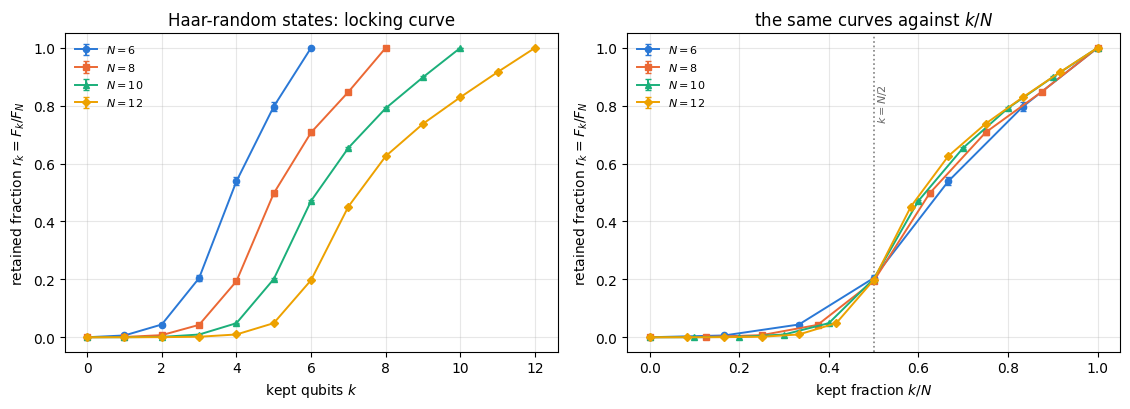

In [7]:
# ==============================================================================
# FIGURE: the Haar locking curve, absolute and rescaled
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.2))
for j, n in enumerate(N_HAAR):
    ks = np.arange(n + 1)
    axes[0].errorbar(ks, haar_mean[n], yerr=haar_sem[n], fmt=MARKERS[j] + "-",
                     color=PALETTE[j], ms=4.5, lw=1.4, capsize=2, label=f"$N={n}$")
    axes[1].errorbar(ks / n, haar_mean[n], yerr=haar_sem[n], fmt=MARKERS[j] + "-",
                     color=PALETTE[j], ms=4.5, lw=1.4, capsize=2, label=f"$N={n}$")
axes[0].set_xlabel("kept qubits $k$")
axes[1].set_xlabel("kept fraction $k/N$")
axes[1].axvline(0.5, color="0.5", ls=":", lw=1.2)
axes[1].text(0.505, 0.75, "$k=N/2$", fontsize=8, color="0.4", rotation=90)
for ax in axes:
    ax.set_ylabel(r"retained fraction $r_k=F_k/F_N$")
    ax.legend(fontsize=8)
axes[0].set_title("Haar-random states: locking curve")
axes[1].set_title("the same curves against $k/N$")
fig.tight_layout()
plt.show()

The right panel is the statement "information about a global property of a random state is not stored anywhere
locally". It is the metrological face of the Page curve, and it is the fixed point that the rest of this
notebook watches two very different dynamics approach.

> **Common pitfall.** The ratio $r_k$ was formed *inside* each realisation and only then averaged. Averaging
> $F_k$ and $F_N$ separately and dividing afterwards is a different estimator: $F_N$ itself fluctuates from state
> to state, and the ratio of means is not the mean of ratios. At $N=12$ with $24$ realisations the two differ by
> more than the quoted error bars at the smallest $k$, which is how a plot that is merely plausible becomes a
> plot that is wrong.

## 5. The analog scrambler: a chaotic spin chain

### 5.1 The Hamiltonian

The analog route stirs the probe by simply letting it evolve. The chain is

$$H_{\text{scr}}=J\sum_{q=0}^{N-2}\left(X_qX_{q+1}+Y_qY_{q+1}\right)+\sum_{q=0}^{N-1}h_qX_q,
\qquad h_q\ \text{drawn uniformly from}\ [-h,h], \tag{4}$$

an open $XX$ chain in a **random transverse field**. The choice is deliberate on both counts.

The bare $XX+YY$ chain is *integrable*: a Jordan-Wigner transformation maps it to free fermions, it conserves
$\sum_qZ_q$, and it does not scramble — it spreads excitations ballistically but it does not make the state
generic. Adding a field along $x$ breaks the conservation of $\sum_qZ_q$ and destroys the free-fermion
structure, and the chain becomes non-integrable. Making the field **random** removes the translation invariance
that would otherwise give extra structure to the spectrum, and it lets us average over disorder realisations
instead of over nothing.

We will use the integrable chain ($h=0$) as a control: it is the scrambler that cannot lock.

### 5.2 Integrating it

$H_{\text{scr}}$ is a sum of two-site bond terms and one-site field terms, which is exactly the input format of
the engine's `tebd_gates`: one second-order Trotter-Suzuki step is a list of small unitaries applied by einsum,
and `lax.scan` runs the step $n$ times inside XLA after compiling it once.

The step size must be chosen, not assumed. The second-order splitting has a global error $O(dt^2)$, but the
prefactor depends on the commutators of the terms, and the disorder strength enters it. So we measure: evolve
to a fixed time with decreasing $dt$, compare against the smallest one, and confirm the slope is $2$ before
trusting any of the physics.

In [8]:
# ==============================================================================
# STEP 3: the chaotic chain and its Trotter step
# ==============================================================================
J_SCR = 1.0            # bond coupling of Eq. (4)
H_SCR = 1.0            # disorder strength of the transverse field


def scrambler_terms(key, n, h=H_SCR, j=J_SCR):
    """Local terms of Eq. (4): open XX+YY bonds plus a random transverse field.

    Returns the engine's term format [(qubits, small hermitian matrix), ...]; h = 0 gives the
    integrable free-fermion chain used as the control in Section 5.5.
    """
    fields = jax.random.uniform(key, (n,), minval=-h, maxval=h)
    terms = [((q, q + 1), j * (XX + YY)) for q in range(n - 1)]
    terms += [((q,), float(fields[q]) * X) for q in range(n)]
    return terms


def make_stepper(terms, dt, order=2):
    """A jitted single Trotter-Suzuki step, and a jitted n-step propagator built with lax.scan.

    JAX    the gate list is a Python list of concrete arrays closed over by the step function, so it is
           baked into the compiled program; `lax.scan` then loops inside XLA instead of unrolling n
           copies of the circuit at trace time.
    """
    gates = tebd_gates(terms, dt, order=order)
    step = jax.jit(lambda p: apply_gates(p, gates))

    @partial(jax.jit, static_argnums=1)
    def evolve(p, n_steps):
        return lax.scan(lambda s, _: (apply_gates(s, gates), None), p, None, length=n_steps)[0]

    return step, evolve


# --- CHECKPOINT: the Trotter step is unitary and the order is 2, measured ---------------
key, sk = jax.random.split(key)
terms_chk = scrambler_terms(sk, N)
T_CHK = 1.0
dts = np.array([0.2, 0.1, 0.05, 0.025, 0.0125])
ref_step, ref_evolve = make_stepper(terms_chk, 0.0015625)
psi_ref = ref_evolve(psi_ghz, int(round(T_CHK / 0.0015625)))
errs = []
for dt in dts:
    _, ev = make_stepper(terms_chk, float(dt))
    out = ev(psi_ghz, int(round(T_CHK / dt)))
    errs.append(float(jnp.linalg.norm((out - psi_ref).reshape(-1))))
errs = np.array(errs)
slope = np.polyfit(np.log(dts), np.log(errs), 1)[0]
print(f"norm after evolution: {float(jnp.vdot(psi_ref, psi_ref).real):.12f}  (must be 1)")
print(f"\n  {'dt':>8} {'||psi(dt) - psi_ref||':>24}")
for dt, e in zip(dts, errs):
    print(f"  {dt:8.5f} {e:24.3e}")
print(f"\nfitted convergence order = {slope:.3f}   (second-order Trotter-Suzuki: 2)")
assert abs(slope - 2.0) < 0.15
assert abs(float(jnp.vdot(psi_ref, psi_ref).real) - 1.0) < 1e6 * TOL

DT_SCR = 0.02          # step size used from here on: the table above puts the error at t = 1 near 6e-4

norm after evolution: 0.999999999995  (must be 1)

        dt    ||psi(dt) - psi_ref||
   0.20000                5.414e-02
   0.10000                1.356e-02
   0.05000                3.389e-03
   0.02500                8.447e-04
   0.01250                2.087e-04

fitted convergence order = 2.004   (second-order Trotter-Suzuki: 2)


### 5.3 One compilation for all disorder realisations

The validation above built a fresh gate list for each $dt$ and let `jax.jit` bake it into the compiled program.
That is the right thing to do once. It is the wrong thing to do in a loop over disorder realisations: each
realisation has different field gates, so each closure is a different Python object, and JAX recompiles the
entire $46$-gate circuit every time. The fix is to make the disorder an **argument**.

The bond gate is the same on every bond and in every realisation, so it stays a constant. The field gates form
an array of shape $(N,2,2)$, which is passed in and traced. One compilation then serves every realisation and
every disorder strength.

Once the disorder is an argument, a second gain follows for free: `jax.vmap` maps the propagator over a whole
batch of realisations, so all six chains of Section 5.4 are evolved by one compiled, batched program rather
than by a Python loop over six.

We write the second-order step by hand in the same symmetric form the engine uses — the full sweep of half-step
gates followed by the reversed sweep — and check it against `tebd_gates` before using it.

In [9]:
# ==============================================================================
# STEP 4: a Trotter step whose disorder is an ARGUMENT, not a compile-time constant
# ==============================================================================
U_BOND_HALF = _expm_herm(J_SCR * (XX + YY), DT_SCR / 2)     # same on every bond: a constant


def analog_step(psi, u_field):
    """One second-order Trotter-Suzuki step of Eq. (4).

    MATH   S_2(dt) = (prod_k e^{-i h_k dt/2}) (prod_k e^{-i h_k dt/2})^{reversed}, the symmetric
           (Strang) product over all bond and field terms -- global error O(dt^2).
    ARGS   u_field : (N, 2, 2) array of single-site half-step propagators exp(-i h_q X dt/2).
    JAX    u_field is a traced ARGUMENT, so one compiled program serves every disorder realisation;
           the loops over q are unrolled at trace time into a single fused XLA program.
    """
    for q in range(N - 1):
        psi = apply_gate(psi, U_BOND_HALF, (q, q + 1))
    for q in range(N):
        psi = apply_gate(psi, u_field[q], (q,))
    for q in reversed(range(N)):
        psi = apply_gate(psi, u_field[q], (q,))
    for q in reversed(range(N - 1)):
        psi = apply_gate(psi, U_BOND_HALF, (q, q + 1))
    return psi


@partial(jax.jit, static_argnums=2)
def analog_evolve(psi, u_field, n_steps):
    """n_steps of `analog_step`, looped inside XLA with lax.scan (compiled once per n_steps)."""
    return lax.scan(lambda s, _: (analog_step(s, u_field), None), psi, None, length=n_steps)[0]


@partial(jax.jit, static_argnums=2)
def analog_evolve_batch(psis, u_fields, n_steps):
    """Evolve a BATCH of states, each under its own disorder realisation.

    JAX    `vmap` turns the single-state propagator into one that maps over the leading axis of both
           arguments. The circuit is compiled once and XLA runs the realisations as a batched program
           instead of as a Python loop -- the same work, one dispatch. Memory is R * 2^N amplitudes,
           which at N = 12 and R = 6 is under a megabyte.
    """
    def one(psi, u_field):
        return lax.scan(lambda st, _: (analog_step(st, u_field), None), psi, None, length=n_steps)[0]

    return jax.vmap(one)(psis, u_fields)


def field_propagators(key, n, h, dt=DT_SCR):
    """Half-step field propagators exp(-i h_q X dt/2) for uniformly random h_q in [-h, h]."""
    fields = jax.random.uniform(key, (n,), minval=-h, maxval=h)
    return jnp.stack([_expm_herm(float(fields[q]) * X, dt / 2) for q in range(n)])


# --- CHECKPOINT: the hand-written step equals the engine's generic one -----------------
key, sk = jax.random.split(key)
fields_chk = jax.random.uniform(sk, (N,), minval=-H_SCR, maxval=H_SCR)
terms_ref = ([((q, q + 1), J_SCR * (XX + YY)) for q in range(N - 1)]
             + [((q,), float(fields_chk[q]) * X) for q in range(N)])
ref_out = apply_gates(psi_ghz, tebd_gates(terms_ref, DT_SCR, order=2))
own_out = analog_step(psi_ghz, jnp.stack([_expm_herm(float(fields_chk[q]) * X, DT_SCR / 2)
                                          for q in range(N)]))
print(f"hand-written step vs engine tebd_gates: max |difference| = {max_abs(own_out - ref_out):.2e}")
assert max_abs(own_out - ref_out) < 1e6 * TOL

hand-written step vs engine tebd_gates: max |difference| = 0.00e+00


### 5.4 Locking in real time

The probe is the GHZ state: the most fragile probe there is, and the one whose locking curve starts as a step
function at $k=N$ — it is the state for which *every* proper subsystem carries exactly zero phase information,
because tracing out even one qubit leaves the classical mixture $\tfrac12(\vert0\cdots0\rangle\langle0\cdots0\vert
+\vert1\cdots1\rangle\langle1\cdots1\vert)$, a mixture of eigenstates of $J_z$, which does not move when the
phase is imprinted.

So at $t=0$ the locking curve is already "locked" in a trivial sense: $r_k=0$ for every $k<N$. What the chaotic
evolution does is *unlock* it first — the information spreads into subsystems and becomes readable from them —
and only then lock it again, this time into the Haar shape. Watching both halves of that story is the point of
the next figure.

We record the locking curve and the half-chain entanglement entropy at eleven times up to $t=16$, averaging over
disorder realisations.

In [10]:
# ==============================================================================
# STEP 5: locking curve and entropy along the chaotic evolution
# ==============================================================================
CHUNK = 25                                     # Trotter steps between recordings: t = 0.5
REC_CHUNKS = [0, 1, 2, 3, 4, 6, 8, 12, 16, 24, 32]
T_REC = np.array(REC_CHUNKS) * CHUNK * DT_SCR  # 0, 0.5, 1, 1.5, 2, 3, 4, 6, 8, 12, 16
R_DIS = 6                                      # disorder realisations, evolved together with vmap

ana_curves = np.zeros((R_DIS, len(REC_CHUNKS), N + 1))
ana_entropy = np.zeros((R_DIS, len(REC_CHUNKS)))
t0 = time.time()
key, *sub = jax.random.split(key, R_DIS + 1)     # sub holds exactly R_DIS independent keys
assert len(sub) == R_DIS
u_fields = jnp.stack([field_propagators(k, N, H_SCR) for k in sub])
psis = jnp.broadcast_to(psi_ghz, (R_DIS,) + psi_ghz.shape)

# --- CHECKPOINT: the batched propagator agrees with the single-state one ---------------
one_by_one = analog_evolve(psi_ghz, u_fields[0], CHUNK)
batched = analog_evolve_batch(psis, u_fields, CHUNK)[0]
print(f"vmapped evolution vs single-state evolution: max |difference| = "
      f"{max_abs(batched - one_by_one):.2e}")
assert max_abs(batched - one_by_one) < 1e6 * TOL

j = 0
for ci in range(max(REC_CHUNKS) + 1):
    if ci > 0:
        psis = analog_evolve_batch(psis, u_fields, CHUNK)
    if ci in REC_CHUNKS:
        for r in range(R_DIS):
            c = locking_curve(psis[r])
            ana_curves[r, j] = c / c[-1]
            ana_entropy[r, j] = half_entropy(psis[r])
        j += 1
ana_mean, ana_sem = ana_curves.mean(0), ana_curves.std(0, ddof=1) / np.sqrt(R_DIS)
ent_mean, ent_sem = ana_entropy.mean(0), ana_entropy.std(0, ddof=1) / np.sqrt(R_DIS)
S_PAGE = page_entropy_bits(N // 2, N - N // 2)
print(f"analog scrambling of a GHZ probe, N = {N}, {R_DIS} disorder realisations, "
      f"{time.time() - t0:.1f} s\n")

print(f"  {'t':>6} {'S_half/bits':>12} {'/Page':>7} | " + " ".join(f"{'k=' + str(k):>8s}" for k in range(1, 8)))
for j, t in enumerate(T_REC):
    print(f"  {t:6.1f} {ent_mean[j]:12.3f} {ent_mean[j] / S_PAGE:7.3f} | "
          + " ".join(f"{ana_mean[j][k]:8.4f}" for k in range(1, 8)))
print(f"\n  Haar reference (N = {N}):      {'':19s}"
      + " ".join(f"{haar_mean[N][k]:8.4f}" for k in range(1, 8)))
print(f"  Page entropy for this cut: {S_PAGE:.3f} bits")

vmapped evolution vs single-state evolution: max |difference| = 0.00e+00


analog scrambling of a GHZ probe, N = 12, 6 disorder realisations, 8.0 s

       t  S_half/bits   /Page |      k=1      k=2      k=3      k=4      k=5      k=6      k=7
     0.0        1.000   0.189 |   0.0000   0.0000   0.0000   0.0000   0.0000   0.0000   0.0000
     0.5        1.037   0.196 |   0.0005   0.0042   0.0077   0.0102   0.0133   0.0156   0.0200
     1.0        1.469   0.278 |   0.0035   0.0148   0.0307   0.0437   0.0572   0.0671   0.0841
     1.5        2.125   0.402 |   0.0025   0.0181   0.0464   0.0785   0.1110   0.1379   0.1711
     2.0        2.792   0.529 |   0.0020   0.0141   0.0368   0.0758   0.1175   0.1652   0.2347
     3.0        3.978   0.753 |   0.0011   0.0060   0.0150   0.0396   0.0861   0.1671   0.2717
     4.0        4.649   0.881 |   0.0005   0.0028   0.0083   0.0219   0.0593   0.1585   0.3104
     6.0        5.059   0.958 |   0.0003   0.0011   0.0040   0.0138   0.0497   0.1756   0.3849
     8.0        5.149   0.975 |   0.0001   0.0008   0.0031   0.0146   0

Read the table down each column. The small-$k$ columns show a two-stage history: a rise, as the phase
information leaks out of the global GHZ coherence into finite blocks of the chain, and then a fall, as it is
carried further and becomes global again. The large-$k$ columns show only the rise — for a block bigger than
half the chain there is nowhere further for the information to go, so it arrives and stays.

Rather than reading the turning points off the table by eye, we locate them.

In [11]:
# ==============================================================================
# STEP 5b: where each block is at its most informative
# ==============================================================================
print(f"  {'k':>3} {'peak r_k':>10} {'at Jt':>8} {'final r_k':>11} {'Haar':>9}   behaviour")
for k in range(1, N):                               # k = N is identically 1 and carries no information
    j = int(np.argmax(ana_mean[:, k]))
    peak, final = ana_mean[j, k], ana_mean[-1, k]
    if j == 0:
        what = "flat"
    elif final > 0.95 * peak:
        what = "rises and saturates"
    else:
        what = f"peaks, then falls to {final / peak:.2f} of the peak"
    print(f"  {k:>3} {ana_mean[j, k]:10.4f} {T_REC[j]:8.1f} {ana_mean[-1, k]:11.4f} "
          f"{haar_mean[N][k]:9.4f}   {what}")

    k   peak r_k    at Jt   final r_k      Haar   behaviour
    1     0.0035      1.0      0.0000    0.0000   peaks, then falls to 0.01 of the peak
    2     0.0181      1.5      0.0007    0.0003   peaks, then falls to 0.04 of the peak
    3     0.0464      1.5      0.0027    0.0017   peaks, then falls to 0.06 of the peak
    4     0.0785      1.5      0.0159    0.0096   peaks, then falls to 0.20 of the peak
    5     0.1175      2.0      0.0543    0.0487   peaks, then falls to 0.46 of the peak
    6     0.1949     12.0      0.1945    0.1974   rises and saturates
    7     0.4379     12.0      0.4332    0.4517   rises and saturates
    8     0.6132     12.0      0.6069    0.6257   rises and saturates
    9     0.7320     12.0      0.7207    0.7378   rises and saturates
   10     0.8315     12.0      0.8136    0.8294   rises and saturates
   11     0.9176     12.0      0.9054    0.9164   rises and saturates


The table splits the register in two at $k=N/2=6$, and the split is sharp. Every block smaller than half the
chain rises to a maximum and then decays back to within a small factor of the Haar value: the information
passes through it. Every block larger than half rises and saturates: the information arrives and has nowhere
else to go.

The maximum drifts to later times as the block grows — $Jt\approx1$ at $k=1$, $Jt\approx2$ at $k=5$ — which is
the signature of a front crossing the chain at finite speed. The recording grid used here is far too coarse to
turn that drift into a velocity; Exercise 8 does the measurement properly and compares the result with the
correlation spreading of notebook 15.

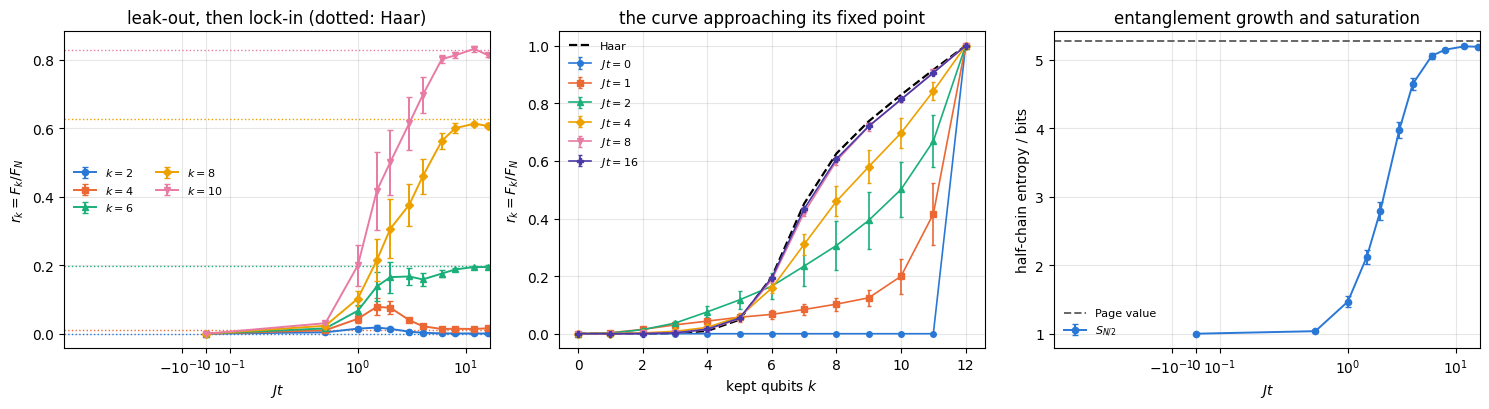

In [12]:
# ==============================================================================
# FIGURE: the two stages of analog locking
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.2))

for j, k in enumerate([2, 4, 6, 8, 10]):
    axes[0].errorbar(T_REC, ana_mean[:, k], yerr=ana_sem[:, k], fmt=MARKERS[j % 6] + "-",
                     color=PALETTE[j % 6], ms=4.5, lw=1.4, capsize=2, label=f"$k={k}$")
    axes[0].axhline(haar_mean[N][k], color=PALETTE[j % 6], ls=":", lw=1.0)
axes[0].set_xscale("symlog", linthresh=0.5)
axes[0].set_xlabel("$Jt$")
axes[0].set_ylabel(r"$r_k=F_k/F_N$")
axes[0].set_title("leak-out, then lock-in (dotted: Haar)")
axes[0].legend(fontsize=8, ncol=2)

for j, ji in enumerate([0, 2, 4, 6, 8, 10]):
    axes[1].errorbar(np.arange(N + 1), ana_mean[ji], yerr=ana_sem[ji], fmt=MARKERS[j] + "-",
                     color=PALETTE[j], ms=4.0, lw=1.2, capsize=1.5, label=f"$Jt={T_REC[ji]:g}$")
axes[1].plot(np.arange(N + 1), haar_mean[N], "k--", lw=1.6, label="Haar")
axes[1].set_xlabel("kept qubits $k$")
axes[1].set_ylabel(r"$r_k=F_k/F_N$")
axes[1].set_title("the curve approaching its fixed point")
axes[1].legend(fontsize=8)

axes[2].errorbar(T_REC, ent_mean, yerr=ent_sem, fmt="o-", color=PALETTE[0], ms=4.5, lw=1.4,
                 capsize=2, label="$S_{N/2}$")
axes[2].axhline(S_PAGE, color="0.4", ls="--", lw=1.4, label="Page value")
axes[2].set_xscale("symlog", linthresh=0.5)
axes[2].set_xlabel("$Jt$")
axes[2].set_ylabel("half-chain entropy / bits")
axes[2].set_title("entanglement growth and saturation")
axes[2].legend(fontsize=8)

fig.tight_layout()
plt.show()

### 5.5 The scrambler that cannot scramble

Setting $h=0$ removes the field and leaves the bare $XX+YY$ chain. On this probe it does **nothing at all**, and
the reason is exact rather than statistical. On the two-site basis states,

$$\left(XX+YY\right)\vert00\rangle=\vert11\rangle-\vert11\rangle=0,\qquad
\left(XX+YY\right)\vert11\rangle=\vert00\rangle-\vert00\rangle=0,$$

because $Y\vert0\rangle=i\vert1\rangle$ and $Y\vert1\rangle=-i\vert0\rangle$ contribute a factor $i\cdot i=-1$
where $X\otimes X$ contributes $+1$. Every bond term annihilates both $\vert0\cdots0\rangle$ and
$\vert1\cdots1\rangle$, so $H_{\text{scr}}\vert\mathrm{GHZ}\rangle=0$ at $h=0$: the GHZ state is an exact
zero-energy eigenstate, a *dark state* of the bare chain. It does not evolve, it does not entangle further, and
it never locks.

The transverse field is what breaks this — it is simultaneously what makes the chain non-integrable and what
connects the GHZ state to the rest of the Hilbert space. Sweeping its strength therefore sweeps the scrambling
rate, and the sweep below shows a dark state, a slow scrambler and a fast one, all at the same final time.

In [13]:
# ==============================================================================
# STEP 6: the same evolution at four disorder strengths, compared at t = 16
# ==============================================================================
H_SWEEP = [0.0, 0.25, 1.0, 2.0]
R_SWEEP = 4
T_FINAL = 16.0
n_chunks_final = int(round(T_FINAL / (CHUNK * DT_SCR)))

sweep_mean, sweep_ent = {}, {}
t0 = time.time()
for h in H_SWEEP:
    rows, ents = [], []
    for r in range(R_SWEEP):
        key, sk = jax.random.split(key)
        u_field = field_propagators(sk, N, h)
        psi = psi_ghz
        for _ in range(n_chunks_final):
            psi = analog_evolve(psi, u_field, CHUNK)
        c = locking_curve(psi)
        rows.append(c / c[-1] if c[-1] > 0 else c)
        ents.append(half_entropy(psi))
    sweep_mean[h] = np.array(rows).mean(0)
    sweep_ent[h] = float(np.mean(ents))
print(f"disorder sweep at Jt = {T_FINAL:g}, {R_SWEEP} realisations each, {time.time() - t0:.1f} s\n")

print(f"  {'h':>5} {'S_half':>8} {'/Page':>7} | " + " ".join(f"{'k=' + str(k):>8s}" for k in range(1, 8)))
for h in H_SWEEP:
    print(f"  {h:5.2f} {sweep_ent[h]:8.3f} {sweep_ent[h] / S_PAGE:7.3f} | "
          + " ".join(f"{sweep_mean[h][k]:8.4f}" for k in range(1, 8)))
print(f"  {'Haar':>5} {S_PAGE:8.3f} {1.0:7.3f} | "
      + " ".join(f"{haar_mean[N][k]:8.4f}" for k in range(1, 8)))

# --- CHECKPOINT: at h = 0 the GHZ state is an exact eigenstate ------------------------
bond_only = [((q, q + 1), J_SCR * (XX + YY)) for q in range(N - 1)]
h_ghz = sum(apply_gate(psi_ghz, m, qs) for qs, m in bond_only)
print(f"\n|| H_bond |GHZ> || = {float(jnp.linalg.norm(h_ghz.reshape(-1))):.2e}   (dark state: exactly 0)")
assert float(jnp.linalg.norm(h_ghz.reshape(-1))) < 1e6 * TOL

disorder sweep at Jt = 16, 4 realisations each, 13.6 s

      h   S_half   /Page |      k=1      k=2      k=3      k=4      k=5      k=6      k=7
   0.00    1.000   0.189 |   0.0000   0.0000   0.0000   0.0000   0.0000   0.0000   0.0000
   0.25    3.042   0.576 |   0.0004   0.0018   0.0093   0.0165   0.0314   0.0560   0.0961
   1.00    5.208   0.987 |   0.0001   0.0006   0.0028   0.0118   0.0534   0.1998   0.4436
   2.00    5.196   0.984 |   0.0001   0.0008   0.0027   0.0124   0.0544   0.1962   0.4370
   Haar    5.279   1.000 |   0.0000   0.0003   0.0017   0.0096   0.0487   0.1974   0.4517

|| H_bond |GHZ> || = 0.00e+00   (dark state: exactly 0)


## 6. Digital scramblers: three gate sets on the same geometry

The digital route replaces continuous evolution by discrete layers. The geometry is the brick wall of
notebook 10: layer $L$ acts with two-qubit gates on the bonds $(q,q+1)$ with $q\equiv L\ (\mathrm{mod}\ 2)$, so
that every qubit is touched every two layers and correlations spread at one site per layer. Depth $L$ plays the
role that time $t$ played in Section 5.

What changes between the three scramblers is only the gate set.

| scrambler | layer | what it can produce |
|---|---|---|
| Haar | a Haar-random $4\times4$ unitary on each brick-wall bond | generic states; the fastest scrambler on this geometry |
| Clifford | a random single-qubit Clifford on every site, then CNOT on each brick-wall bond | **stabilizer states only** |
| Clifford $+$ $n_T$ T | the Clifford layer plus $T$ gates on $n_T$ randomly chosen sites | stabilizer states doped with magic |

The middle row is the interesting one. By the Gottesman-Knill theorem (notebook 27) a Clifford circuit acting on
a stabilizer state — and $\vert\mathrm{GHZ}\rangle$ is one — produces a stabilizer state, which can be simulated
classically in polynomial time and which has **zero magic**. Such states are nonetheless highly entangled: a
random stabilizer state has close to the Page entropy. So the Clifford scrambler lets us ask a sharp question:
is volume-law entanglement enough to lock the metrological information into the Haar shape, or does locking also
need the state to be generic in a way that entanglement does not capture?

> **Physics insight.** A stabilizer state has a rigid structure: every reduced density matrix is proportional to
> a projector, its spectrum is flat, and its entropy is an integer number of bits. That rigidity propagates into
> the locking curve, which can only take values in a discrete set. Nothing in the entanglement entropy prepares
> a reader for that, which is exactly why it is worth measuring.

In [14]:
# ==============================================================================
# STEP 7: the three digital layers
# ==============================================================================
CLIFFORDS = single_qubit_cliffords()            # the 24 single-qubit Cliffords, from the engine
N_T_DOPE = 2                                    # T gates per layer in the doped circuit


def brick_bonds(n, layer):
    """Bonds touched by brick-wall layer `layer` of an open chain of n qubits."""
    return [(q, q + 1) for q in range(layer % 2, n - 1, 2)]


def layer_haar(key, psi, layer):
    """One brick-wall layer of Haar-random two-qubit gates."""
    for b in brick_bonds(psi.ndim, layer):
        key, sub = jax.random.split(key)
        psi = apply_gate(psi, haar_unitary(sub, 4), b)
    return psi


def layer_clifford(key, psi, layer, n_t=0):
    """One brick-wall Clifford layer, optionally doped with n_t T gates on random sites.

    A random single-qubit Clifford on every site, then CNOT on every bond of the layer. With n_t = 0
    the circuit maps stabilizer states to stabilizer states; each T gate injects one unit of magic.
    """
    n = psi.ndim
    k1, k2 = jax.random.split(key)
    idx = jax.random.randint(k1, (n,), 0, len(CLIFFORDS))
    for q in range(n):
        psi = apply_gate(psi, CLIFFORDS[idx[q]], (q,))
    if n_t > 0:
        sites = np.asarray(jax.random.choice(k2, n, (n_t,), replace=False))
        for q in sites:
            psi = apply_gate(psi, T, (int(q),))
    for b in brick_bonds(n, layer):
        psi = apply_gate(psi, CNOT, b)
    return psi


DIGITAL = {"Haar": layer_haar,
           "Clifford": partial(layer_clifford, n_t=0),
           f"Clifford + {N_T_DOPE}T": partial(layer_clifford, n_t=N_T_DOPE)}

In [15]:
# ==============================================================================
# STEP 8: locking curve and entropy versus circuit depth
# ==============================================================================
DEPTHS = [0, 1, 2, 3, 4, 6, 8, 12, 16, 24, 32]
R_CIRC = 6                                       # circuit realisations per gate set

dig_mean, dig_sem, dig_ent, dig_ent_raw = {}, {}, {}, {}
t0 = time.time()
for name, layer in DIGITAL.items():
    curves = np.zeros((R_CIRC, len(DEPTHS), N + 1))
    ents = np.zeros((R_CIRC, len(DEPTHS)))
    for r in range(R_CIRC):
        key, sk = jax.random.split(key)
        psi, j = psi_ghz, 0
        for L in range(max(DEPTHS) + 1):
            if L > 0:
                sk, sub = jax.random.split(sk)
                psi = layer(sub, psi, L - 1)
            if L in DEPTHS:
                c = locking_curve(psi)
                curves[r, j] = c / c[-1]
                ents[r, j] = half_entropy(psi)
                j += 1
    dig_mean[name] = curves.mean(0)
    dig_sem[name] = curves.std(0, ddof=1) / np.sqrt(R_CIRC)
    dig_ent[name] = ents.mean(0)
    dig_ent_raw[name] = ents
print(f"three digital scramblers, {R_CIRC} circuit realisations each, {time.time() - t0:.1f} s\n")

for name in DIGITAL:
    print(f"  --- {name} ---")
    print(f"  {'L':>4} {'S_half':>8} {'/Page':>7} | " + " ".join(f"{'k=' + str(k):>8s}" for k in range(1, 8)))
    for j, L in enumerate(DEPTHS):
        print(f"  {L:4d} {dig_ent[name][j]:8.3f} {dig_ent[name][j] / S_PAGE:7.3f} | "
              + " ".join(f"{dig_mean[name][j][k]:8.4f}" for k in range(1, 8)))
    print()
print(f"  {'Haar reference':>21s} {'':7s} | " + " ".join(f"{haar_mean[N][k]:8.4f}" for k in range(1, 8)))

# --- CHECKPOINT: every Clifford realisation has an INTEGER half-chain entropy ----------
cliff_ents = dig_ent_raw["Clifford"]
dev = float(np.max(np.abs(cliff_ents - np.round(cliff_ents))))
print(f"\nClifford circuits: max deviation of S_half from an integer number of bits = {dev:.2e}")
print(f"  (Haar circuits, for contrast, at depth {DEPTHS[-1]}: "
      f"S_half = {dig_ent['Haar'][-1]:.4f} bits, Page = {S_PAGE:.4f})")
assert dev < 1e6 * TOL

three digital scramblers, 6 circuit realisations each, 17.4 s

  --- Haar ---
     L   S_half   /Page |      k=1      k=2      k=3      k=4      k=5      k=6      k=7
     0    1.000   0.189 |   0.0000   0.0000   0.0000   0.0000   0.0000   0.0000   0.0000
     1    1.000   0.189 |   0.0070   0.1075   0.1720   0.3072   0.3472   0.4432   0.4793
     2    1.785   0.338 |   0.0063   0.0455   0.1910   0.2693   0.3870   0.4445   0.5656
     3    1.785   0.338 |   0.0045   0.0540   0.1196   0.2477   0.3180   0.4355   0.4978
     4    2.696   0.511 |   0.0051   0.0431   0.1166   0.1880   0.3335   0.3881   0.5415
     6    3.399   0.644 |   0.0030   0.0149   0.0761   0.1288   0.3059   0.3819   0.5204
     8    3.960   0.750 |   0.0024   0.0096   0.0449   0.0940   0.2314   0.3203   0.4899
    12    4.665   0.884 |   0.0006   0.0035   0.0196   0.0442   0.1422   0.2728   0.4803
    16    5.053   0.957 |   0.0002   0.0020   0.0093   0.0274   0.0946   0.2353   0.4644
    24    5.246   0.994 |   0.00

The Clifford column is the one to read carefully. Its entanglement entropy climbs to within a few per cent of
the Page value — by that measure the state is as scrambled as a random one — and yet its locking curve is a
different object: the small-$k$ entries are not small, they are **exactly zero**, and the entries that are not
zero sit on a coarse grid of rational numbers. A stabilizer reduced state is proportional to a projector, so
$F_k$ is a sum of a few equal terms and can only land on particular values. The curve is a staircase, not the
smooth Haar profile.

Adding two $T$ gates per layer — a vanishing fraction of the roughly $N+N/2$ gates in a layer — destroys the
staircase: the exact zeros become small non-zero numbers and the curve returns to the same smooth shape the
Haar circuit produces, agreeing with the Haar reference to within a factor of about two at $k=3$ at the depths
reached here. Magic is what makes a scrambled state *generic*, and genericity, not entanglement, is what the
locking curve is sensitive to. This is the same lesson as notebook 27, arriving from the metrological side.

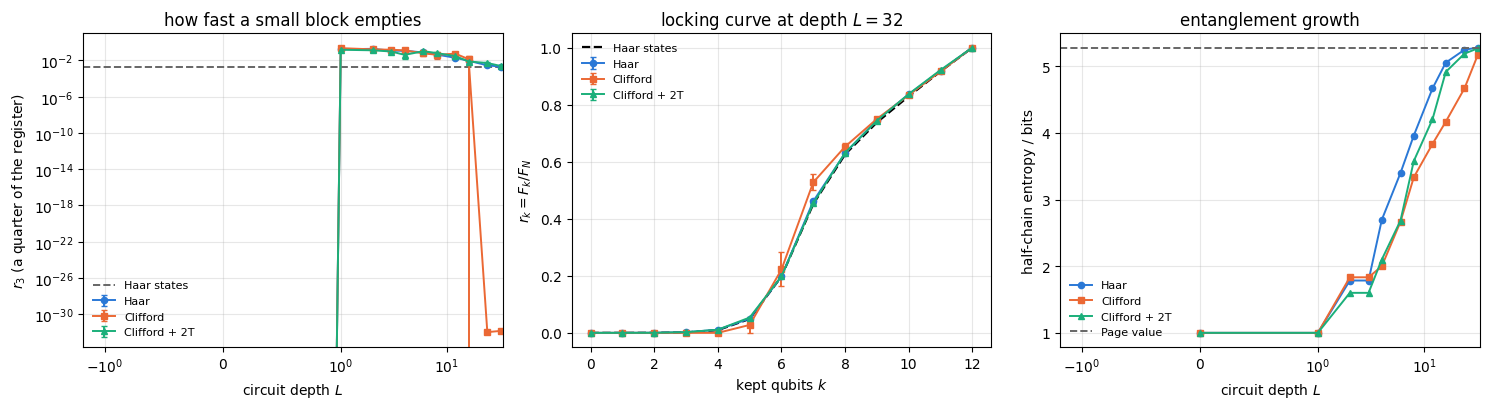

In [16]:
# ==============================================================================
# FIGURE: three gate sets, same geometry
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.2))

for j, name in enumerate(DIGITAL):
    axes[0].errorbar(DEPTHS, dig_mean[name][:, 3], yerr=dig_sem[name][:, 3],
                     fmt=MARKERS[j] + "-", color=PALETTE[j], ms=4.5, lw=1.4, capsize=2, label=name)
axes[0].axhline(haar_mean[N][3], color="0.4", ls="--", lw=1.4, label="Haar states")
axes[0].set_xscale("symlog", linthresh=1.0)
axes[0].set_yscale("log")
axes[0].set_xlabel("circuit depth $L$")
axes[0].set_ylabel("$r_3$ (a quarter of the register)")
axes[0].set_title("how fast a small block empties")
axes[0].legend(fontsize=8)

ks = np.arange(N + 1)
for j, name in enumerate(DIGITAL):
    axes[1].errorbar(ks, dig_mean[name][-1], yerr=dig_sem[name][-1], fmt=MARKERS[j] + "-",
                     color=PALETTE[j], ms=4.5, lw=1.4, capsize=2, label=name)
axes[1].plot(ks, haar_mean[N], "k--", lw=1.6, label="Haar states")
axes[1].set_xlabel("kept qubits $k$")
axes[1].set_ylabel(r"$r_k=F_k/F_N$")
axes[1].set_title(f"locking curve at depth $L={DEPTHS[-1]}$")
axes[1].legend(fontsize=8)

for j, name in enumerate(DIGITAL):
    axes[2].plot(DEPTHS, dig_ent[name], MARKERS[j] + "-", color=PALETTE[j], ms=4.5, lw=1.4, label=name)
axes[2].axhline(S_PAGE, color="0.4", ls="--", lw=1.4, label="Page value")
axes[2].set_xscale("symlog", linthresh=1.0)
axes[2].set_xlabel("circuit depth $L$")
axes[2].set_ylabel("half-chain entropy / bits")
axes[2].set_title("entanglement growth")
axes[2].legend(fontsize=8)

fig.tight_layout()
plt.show()

## 7. The volume law, and why it is not the whole story

The mechanism proposed in Section 1 was the volume law: locking should follow entanglement. Sections 5 and 6
both produced entropies that climb to the Page value and locking curves that approach the Haar shape, which is
consistent. This section asks whether the two happen *at the same time*, and the answer is no.

First the structural check. The entanglement entropy of a random pure state is not proportional to $k$ for all
$k$ — it follows the Page curve, which is close to $k$ bits for $k<N/2$ (volume law, the small block is nearly
maximally mixed) and bends over to the same value on the other side by purity. We compute the full profile
$S_k$ for the final state of every scrambler and compare with Page.

In [17]:
# ==============================================================================
# STEP 9: entropy profile of every final state, against the Page curve
# ==============================================================================
def entropy_profile(psi):
    """S_k in bits for the LAST k qubits against the rest, k = 0..N (same cut as the locking curve)."""
    n = psi.ndim
    return np.array([0.0] + [float(entanglement_entropy(psi, range(n - k, n))) for k in range(1, n + 1)])


page_profile = np.array([0.0] + [page_entropy_bits(k, N - k) for k in range(1, N + 1)])

# final states: the analog chain at Jt = 16, and each digital circuit at the largest depth
key, sk = jax.random.split(key)
psi_analog_final = psi_ghz
u_field_final = field_propagators(sk, N, H_SCR)
for _ in range(n_chunks_final):
    psi_analog_final = analog_evolve(psi_analog_final, u_field_final, CHUNK)

final_states = {f"analog, $Jt={T_FINAL:g}$": psi_analog_final}
for name, layer in DIGITAL.items():
    key, sk = jax.random.split(key)
    psi = psi_ghz
    for L in range(max(DEPTHS)):
        sk, sub = jax.random.split(sk)
        psi = layer(sub, psi, L)
    final_states[f"{name}, $L={max(DEPTHS)}$"] = psi

key, sk = jax.random.split(key)
final_states["Haar state"] = haar_state(sk, N)

profiles = {name: entropy_profile(psi) for name, psi in final_states.items()}
print("entanglement entropy profile S_k (bits) of the final states\n")
print(f"  {'k':>3} {'Page':>8} | " + " ".join(f"{name.split(',')[0][:12]:>13s}" for name in profiles))
for k in range(N + 1):
    print(f"  {k:>3} {page_profile[k]:8.3f} | " + " ".join(f"{profiles[n][k]:13.3f}" for n in profiles))

entanglement entropy profile S_k (bits) of the final states

    k     Page |        analog          Haar      Clifford  Clifford + 2    Haar state
    0    0.000 |         0.000         0.000         0.000         0.000         0.000
    1    0.999 |         1.000         1.000         1.000         1.000         0.997
    2    1.997 |         1.993         1.999         2.000         1.995         1.995
    3    2.989 |         2.973         2.991         2.000         2.965         2.986
    4    3.955 |         3.922         3.956         3.000         3.917         3.953
    5    4.820 |         4.728         4.817         4.000         4.770         4.825
    6    5.279 |         5.178         5.281         5.000         5.183         5.273
    7    4.820 |         4.768         4.819         5.000         4.704         4.821
    8    3.955 |         3.921         3.956         4.000         3.922         3.959
    9    2.989 |         2.984         2.991         3.000         2.

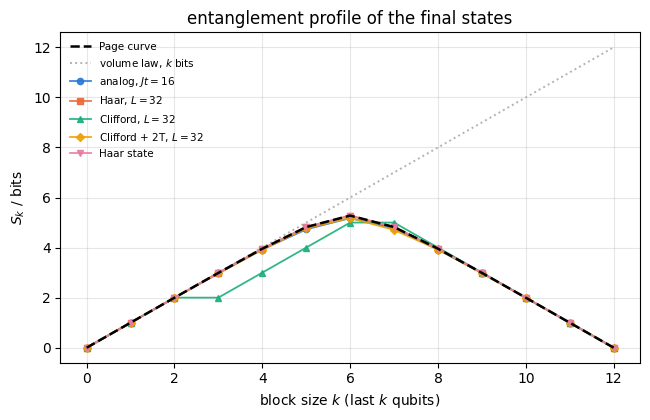

In [18]:
# ==============================================================================
# FIGURE: every scrambler builds the Page profile -- including the Clifford one
# ==============================================================================
fig, ax = plt.subplots(figsize=(6.6, 4.3))
ks = np.arange(N + 1)
ax.plot(ks, page_profile, "k--", lw=1.8, label="Page curve", zorder=5)
ax.plot(ks, ks * 1.0, color="0.7", ls=":", lw=1.4, label="volume law, $k$ bits")
for j, (name, prof) in enumerate(profiles.items()):
    ax.plot(ks, prof, MARKERS[j] + "-", color=PALETTE[j], ms=4.5, lw=1.3, alpha=0.9, label=name)
ax.set_xlabel("block size $k$ (last $k$ qubits)")
ax.set_ylabel("$S_k$ / bits")
ax.set_title("entanglement profile of the final states")
ax.legend(fontsize=7.5)
fig.tight_layout()
plt.show()

Every scrambler produces a volume law: the profile rises at close to one bit per qubit up to the half-way point
and bends over exactly as Page's curve does. By this diagnostic all four states are equivalent, and the Clifford
state is no exception — its profile is a staircase of integers, but it tracks the same envelope.

Now the timing. For each scrambler we locate the point at which the half-chain entropy first reaches $95\%$ of
its Page value, and compare it with what the locking curve is doing at the same moment.

In [19]:
# ==============================================================================
# STEP 10: entropy saturation time versus locking time
# ==============================================================================
def first_crossing(x, y, level):
    """Smallest x at which the piecewise-linear interpolant of y(x) reaches `level` (nan if never)."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    for i in range(1, len(x)):
        if y[i] >= level > y[i - 1]:
            f = (level - y[i - 1]) / (y[i] - y[i - 1])
            return x[i - 1] + f * (x[i] - x[i - 1])
    return np.nan


def interp_at(x, y, x0):
    """Piecewise-linear interpolation of y(x) at x0 (nan outside the range)."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    return float(np.interp(x0, x, y)) if np.isfinite(x0) and x[0] <= x0 <= x[-1] else np.nan


K_PROBE = 3                                     # a quarter of the register
haar_r3 = haar_mean[N][K_PROBE]

rows = [("analog (chaotic chain)", T_REC, ent_mean, ana_mean[:, K_PROBE], "$Jt$")]
rows += [(name, DEPTHS, dig_ent[name], dig_mean[name][:, K_PROBE], "$L$") for name in DIGITAL]

print(f"entropy saturation versus locking, probed at k = {K_PROBE} "
      f"(Haar value r_{K_PROBE} = {haar_r3:.5f})\n")
print(f"  {'scrambler':>22s} {'axis':>6} {'x95':>8} | {'r_3/Haar':>9} {'at x95':>7} | "
      f"{'r_3/Haar':>9} {'at end':>7} {'S/Page':>8}")
gap = {}
for name, xs, ent, r3, axis in rows:
    x95 = first_crossing(xs, ent, 0.95 * S_PAGE)
    r3_at_95 = interp_at(xs, r3, x95)
    gap[name] = (x95, ent[-1] / S_PAGE, r3[-1], r3[-1] / haar_r3, r3_at_95 / haar_r3)
    print(f"  {name:>22s} {axis:>6} {x95:8.2f} | {r3_at_95 / haar_r3:9.1f} "
          f"{'x' + str(1):>7} | {r3[-1] / haar_r3:9.1f} {'':>7} {ent[-1] / S_PAGE:8.3f}")
print(f"\n  x95 = the time or depth at which the half-chain entropy first reaches 95% of the Page value;")
print(f"  'at end' = the last point of each run (Jt = {T_REC[-1]:g} for the analog chain, L = {DEPTHS[-1]} for the circuits).")

entropy saturation versus locking, probed at k = 3 (Haar value r_3 = 0.00172)

               scrambler   axis      x95 |  r_3/Haar  at x95 |  r_3/Haar  at end   S/Page
  analog (chaotic chain)   $Jt$     5.78 |       2.6      x1 |       1.6            0.984
                    Haar    $L$    15.61 |       6.0      x1 |       1.2            1.000
                Clifford    $L$    29.57 |       0.0      x1 |       0.0            0.979
           Clifford + 2T    $L$    18.97 |       3.9      x1 |       1.4            0.998

  x95 = the time or depth at which the half-chain entropy first reaches 95% of the Page value;
  'at end' = the last point of each run (Jt = 16 for the analog chain, L = 32 for the circuits).


Compare the two "r_3 / Haar" columns. At the moment the entropy first reaches $95\%$ of its Page value the
state is, by the entanglement diagnostic, essentially scrambled — and yet a block of three qubits still carries
several times the phase information a Haar-random state would leave it. Run each scrambler on for the rest of
its window and the excess falls to order unity. The lag is real, and it is a factor of a few rather than an
order of magnitude; the honest summary is that the entropy reaches its asymptote first and the locking curve
follows it.

(The Clifford row is a different phenomenon and should not be read as fast locking: its $r_3$ is exactly zero
because a stabilizer reduced state admits no intermediate values, not because it has finished scrambling.)

The reason for the lag is a mismatch of sensitivities. The entropy of a small block saturates as soon as its reduced state
is *close* to maximally mixed, and it approaches that limit smoothly: an error $\epsilon$ in the reduced state
costs only $O(\epsilon^2)$ in entropy near the maximum, because the entropy is stationary there. The quantum
Fisher information is not stationary at the maximally mixed point — it is *zero* there and grows linearly in
the deviation. A residual structure far too small to register in $S_k$ is therefore still plainly visible in
$F_k$.

> **Physics insight.** This is worth remembering outside metrology. Entanglement entropy is a coarse probe of
> how random a reduced state is: it is the first thing to saturate and the last thing to notice a small
> deviation. If a question is about what can still be *extracted* from a subsystem, the entropy will say
> "nothing left" long before it is true.

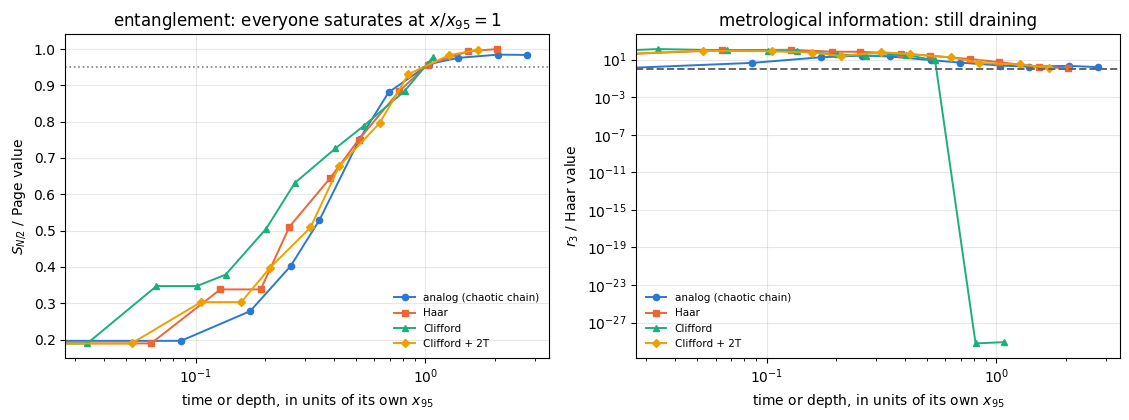

In [20]:
# ==============================================================================
# FIGURE: rescaled by each scrambler's own saturation scale, the curves collapse
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.3))

for j, (name, xs, ent, r3, axis) in enumerate(rows):
    axes[0].plot(np.asarray(xs) / gap[name][0], np.asarray(ent) / S_PAGE,
                 MARKERS[j] + "-", color=PALETTE[j], ms=4.5, lw=1.4, label=name)
    axes[1].plot(np.asarray(xs) / gap[name][0], np.asarray(r3) / haar_r3,
                 MARKERS[j] + "-", color=PALETTE[j], ms=4.5, lw=1.4, label=name)
axes[0].axhline(0.95, color="0.5", ls=":", lw=1.2)
axes[0].set_ylabel("$S_{N/2}$ / Page value")
axes[0].set_title("entanglement: everyone saturates at $x/x_{95}=1$")
axes[1].axhline(1.0, color="0.4", ls="--", lw=1.4)
axes[1].set_yscale("log")
axes[1].set_ylabel(r"$r_3$ / Haar value")
axes[1].set_title("metrological information: still draining")
for ax in axes:
    ax.set_xscale("log")
    ax.set_xlabel("time or depth, in units of its own $x_{95}$")
    ax.legend(fontsize=7.5)
fig.tight_layout()
plt.show()

Rescaling each scrambler by its own saturation scale collapses the entropy curves, as it must — that is what
the rescaling was built to do. The right-hand panel is the content: at $x/x_{95}=1$, where the left panel says
"saturated", the ratio on the right is still well above one, and it keeps falling afterwards. The two clocks
differ, and the metrological one runs behind.

## 8. Cost

Three quantities dominate the notebook, and it is worth knowing which one to worry about as $N$ grows.

* **One Trotter step** applies $2(N-1)$ bond gates and $2N$ field gates, each an einsum over one or two axes of
  a $2^N$ tensor: $O(N2^N)$ time, $O(2^N)$ memory. Cheap, and the whole evolution is one compiled program.
* **One brick-wall layer** applies $\lfloor N/2\rfloor$ two-qubit gates plus (for the Clifford sets) $N$
  single-qubit gates: the same $O(N2^N)$.
* **One point of the locking curve** costs a thin QR and a Hermitian eigendecomposition of dimension
  $2^{\min(k,N-k)}$, so $O(8^{\min(k,N-k)})$, peaking at $8^{N/2}=2^{1.5N}$ in the middle of the curve. *This*
  is the wall. It grows faster than the state vector: at $N=12$ the midpoint eigendecomposition is $64\times64$
  and invisible, at $N=20$ it is $1024\times1024$ and dominates everything else, at $N=26$ it is out of reach
  while the state vector is still comfortable.

The practical consequence is that this notebook's $N$ is limited by the *diagnostic*, not by the simulation.
Evolving a chaotic chain of $N=24$ qubits is routine; computing the full locking curve of the result is not.
Exercise 7 explores what can be done about it.

In [21]:
# ==============================================================================
# STEP 11: measured cost of the three ingredients at N = 12
# ==============================================================================
key, sk = jax.random.split(key)
u_field_bench = field_propagators(sk, N, H_SCR)
_, c_step, t_step = timed(lambda p: analog_evolve(p, u_field_bench, CHUNK), psi_ghz)
key, sk = jax.random.split(key)
_, c_layer, t_layer = timed(jax.jit(lambda p: layer_haar(sk, p, 0)), psi_ghz)

print(f"{'operation':<44} {'compile':>10} {'run':>12}")
print(f"{f'{CHUNK} Trotter steps (one scan program)':<44} {c_step:9.3f}s {t_step * 1e3:10.2f} ms")
print(f"{'one Haar brick-wall layer':<44} {c_layer:9.3f}s {t_layer * 1e3:10.2f} ms")
for k in (1, N // 2, N - 1):
    phi_b = 0.5 * apply_collective(psi_analog_final, Z)
    _, c_k, t_k = timed(_qfi_at_k(k), psi_analog_final, phi_b)
    print(f"{f'one locking-curve point, k = {k:2d}':<44} {c_k:9.3f}s {t_k * 1e3:10.2f} ms")

operation                                       compile          run
25 Trotter steps (one scan program)              0.023s      21.66 ms
one Haar brick-wall layer                        0.942s       0.20 ms
one locking-curve point, k =  1                  0.000s       0.04 ms


one locking-curve point, k =  6                  0.001s       0.90 ms
one locking-curve point, k = 11                  0.000s       0.16 ms


## 9. Key takeaways

* The **locking curve** $r_k=F_k/F_N$ measures how much of a globally imprinted phase survives in $k$ qubits of
  the register. It is a property of the pair (state, generator), not of the state alone, and it is the
  metrological counterpart of the Page curve.
* For a **Haar-random state** the curve is strongly asymmetric: fewer than half the qubits retain essentially
  nothing (suppressed as $4^{k}/2^{N}$), the midpoint retains about a fifth, and the last qubits retain almost
  everything. Rescaled by $k/N$ the curves for different $N$ collapse and sharpen towards a step at $1/2$.
* A **chaotic spin chain** locks a GHZ probe in two stages: the information first leaks out of the global
  coherence into finite blocks, with a light-cone delay that grows with block size, and is then carried away
  again until only blocks larger than $N/2$ retain it.
* Locking requires the scrambler to be able to move the state at all. The bare $XX+YY$ chain annihilates both
  $\vert0\cdots0\rangle$ and $\vert1\cdots1\rangle$, so the GHZ state is an exact **dark state** and never
  locks, however long it is evolved. The random transverse field is simultaneously what makes the chain
  non-integrable and what couples the probe to the rest of the Hilbert space.
* **Digital and analog scramblers reach the same fixed point**, and on their own natural time scales they get
  there at a comparable rate.
* **Clifford circuits are the exception that proves the rule.** They build volume-law entanglement to within a
  few per cent of the Page value, yet their locking curve is a staircase with exactly-zero plateaus rather than
  the smooth Haar profile, because a stabilizer reduced state is proportional to a projector. A couple of $T$
  gates per layer restore the Haar curve. Genericity, not entanglement, is what the locking curve measures.
* **Entanglement entropy saturates before the metrological information is locked.** Measured here, at the point
  where a scrambler first reaches $95\%$ of the Page entropy a quarter of the register still holds several times
  the Haar value of $F_k$; the excess decays over the remainder of the run. The entropy is stationary at the
  maximally mixed point and the quantum Fisher information is not, so $F_k$ resolves residual structure that
  $S_k$ cannot see.
* The cost of the whole study is set by the **diagnostic**, not the dynamics: a locking curve costs
  $O(2^{1.5N})$ while the evolution costs $O(N2^{N})$.

## 10. Exercises

1. (&#9733;) **The midpoint value.** Measure $r_{N/2}$ for Haar-random states at $N=4,6,8,10,12$ and plot it
   against $N$. Does it converge, and to what? Compare with the value $0.5$ that a naive "half the qubits, half
   the information" argument would give, and explain the discrepancy using the fact that $F_k$ is not additive.
2. (&#9733;) **A different generator.** Repeat Section 4 with $J_x$ and with a *staggered* generator
   $\sum_q(-1)^qZ_q/2$. Does the Haar locking curve depend on the generator? Should it? (Consider what a Haar
   average does to a fixed operator.)
3. (&#9733;&#9733;) **Another probe.** Replace the GHZ probe by the optimally squeezed one-axis-twisting state
   of notebook 33 and by $\vert+\rangle^{\otimes N}$. Which one loses its advantage fastest under the chaotic
   chain, measured at fixed $Jt$? Does the *final* locked curve depend on the probe at all?
4. (&#9733;&#9733;) **Disorder and the locking rate.** Extend the sweep of Section 5.5 into a rate measurement:
   for each $h$, find the time at which $r_3$ first falls below twice its Haar value, and plot that time against
   $h$. Is the dependence monotonic? What happens at very large $h$, where the field dominates the bonds, and
   why is that limit also a bad scrambler?
5. (&#9733;&#9733;) **Extend the code: the magic of the doped circuits.** Compute the stabilizer Renyi entropy
   $M_2$ (notebook 27) of the final states of all three digital scramblers, as a function of the number of $T$
   gates per layer, and plot the deviation of the locking curve from the Haar reference against $M_2$. Is the
   relation monotonic?
6. (&#9733;&#9733;) **Where the staircase comes from.** For a Clifford final state, print the eigenvalues of
   $\rho_k$ for $k=1,\dots,N$ and confirm that each is $2^{-S_k}$ with multiplicity $2^{S_k}$. Use this to
   predict, by hand, the set of values $r_k$ is allowed to take, and check the prediction against the numbers
   produced in Section 6.
7. (&#9733;&#9733;&#9733;) **Beating the diagnostic wall.** The $O(8^{N/2})$ cost comes from a dense
   eigendecomposition. Replace it with a Lanczos-based estimate of the sum in Eq. (1) that uses only
   matrix-vector products with $\rho_k$, and measure the accuracy against the exact value at $N=12$ before
   trusting it at $N=16$. How many Lanczos steps are needed for three significant digits?
8. (&#9733;&#9733;&#9733;) **Physics: locking versus the light cone.** Section 5.4 found that the peak of
   $r_k(t)$ moves to later times as $k$ grows. Extract the peak time $t^\ast(k)$ and test whether it is linear
   in $k$. If it is, the slope is a velocity; compare it with the velocity of correlation spreading measured in
   notebook 15 for the same chain, and say whether the two should agree.

## 11. References

* D. N. Page, *Average entropy of a subsystem*, Phys. Rev. Lett. **71**, 1291 (1993) — the Page curve used as
  the entanglement reference throughout.
* P. Hayden and J. Preskill, *Black holes as mirrors: quantum information in random subsystems*,
  J. High Energy Phys. **2007**(09), 120 (2007) — the half-system threshold for recovering information from a
  scrambled system.
* D. A. Roberts and B. Yoshida, *Chaos and complexity by design*, J. High Energy Phys. **2017**(04), 121 (2017)
  — scrambling, Haar randomness and the role of the gate set.
* A. Nahum, J. Ruhman, S. Vijay and J. Haah, *Quantum entanglement growth under random unitary dynamics*,
  Phys. Rev. X **7**, 031016 (2017) — entanglement growth and saturation in brick-wall circuits.
* S. L. Braunstein and C. M. Caves, *Statistical distance and the geometry of quantum states*,
  Phys. Rev. Lett. **72**, 3439 (1994) — the quantum Fisher information and the symmetric logarithmic
  derivative.
* L. Pezze, A. Smerzi, M. K. Oberthaler, R. Schmied and P. Treutlein, *Quantum metrology with nonclassical
  states of atomic ensembles*, Rev. Mod. Phys. **90**, 035005 (2018) — the metrological context.
* G. Toth and I. Apellaniz, *Quantum metrology from a quantum information science perspective*,
  J. Phys. A: Math. Theor. **47**, 424006 (2014) — quantum Fisher information of mixed and reduced states.
* D. Gottesman, *The Heisenberg representation of quantum computers*, arXiv:quant-ph/9807006 (1998) — the
  Gottesman-Knill theorem behind the Clifford scrambler.
* L. Leone, S. F. E. Oliviero and A. Hamma, *Stabilizer Renyi entropy*, Phys. Rev. Lett. **128**, 050402 (2022)
  — magic as a resource, used in Section 6 and Exercise 5.
* F. Mezzadri, *How to generate random matrices from the classical compact groups*, Notices Am. Math. Soc.
  **54**, 592 (2007) — the QR recipe behind `haar_unitary`.
* M. Suzuki, *Fractal decomposition of exponential operators with applications to many-body theories and Monte
  Carlo simulations*, Phys. Lett. A **146**, 319 (1990) — the splitting used by the Trotter step.
* W. H. Press, S. A. Teukolsky, W. T. Vetterling and B. P. Flannery, *Numerical Recipes: The Art of Scientific
  Computing*, 3rd ed., Cambridge University Press (2007) — Chapter 11 for the symmetric eigenproblem and
  Chapter 2 for the QR factorisation used to compress the active subspace.

---
**About these lectures.** Written by Marcin Płodzień (Institute of Theoretical Physics, Jagiellonian University; [ORCID](https://orcid.org/0000-0002-0835-1644), [GitHub](https://github.com/MarcinPlodzien)) as self-study material for the course *Quantum Many-Body Simulation: from a single spin to quantum machine learning*. The notebook is self-contained: the *Engine recap* cell holds every function of the SmoQ.jax engine it uses. If you use this material in teaching or research, please credit the author:

> M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning*, hands-on lectures in JAX with the SmoQ.jax engine (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/